9.292150374779343e-27
(10, 2)


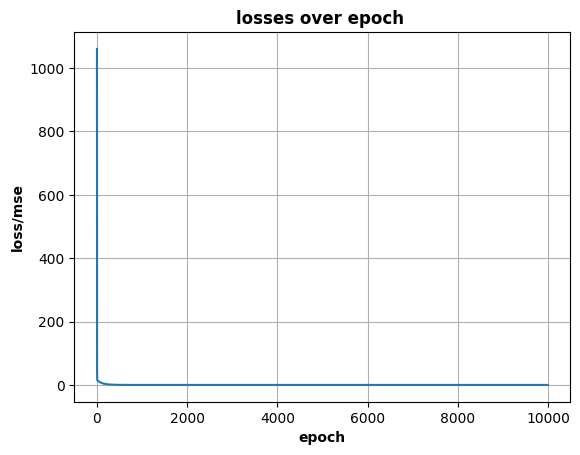

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
class GD:
    def __init__(self, epoch, lr):
        self.lr = lr
        self.epoch = epoch

    def fit(self, x, y):
        m = np.ones(x.shape[1])
        b = 0
        all_loss=[]
        all_m=[]
        all_b=[]
        for i in range(self.epoch):

            y_hat = x @ m + b
            er11=(y-y_hat)**2
            error1=np.sum(er11)/len(y)
            weight_der = (-2 / len(y)) * x.T@(y - y_hat)
            bias_der = np.mean(-2 * (y - y_hat))

            m -= self.lr * weight_der
            b -= self.lr * bias_der
            all_loss.append(error1)
            all_m.append(m)
            all_b.append(b)
        return m, b,all_loss, all_m, all_b

    def predict(self, x, m, b):
        return x @ m + b
    def mse(self,x,y,m,b):
      y_hat=x@m+b
      er1=(y-y_hat)**2
      error=np.sum(er1)/len(y)
      return error

df = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "hours_sleep":   [2, 1, 4, 3, 6, 5, 8, 7, 10, 9],
    "marks":         [19, 16, 31, 28, 43, 40, 55, 52, 67, 64]
})

x=df[["hours_studied",
    "hours_sleep"]].values
y=df["marks"].values
model=GD(10000,0.01)
ypred=model.fit(x,y)
y_pred2=model.predict(x,ypred[0], ypred[1])
error=model.mse(x,y,ypred[0], ypred[1])
print(error)
print(x.shape)
plt.plot(ypred[2])
plt.xlabel("epoch",fontweight="bold")
plt.ylabel("loss/mse", fontweight="bold")
plt.title("losses over epoch ", fontweight="bold")
plt.grid(True)

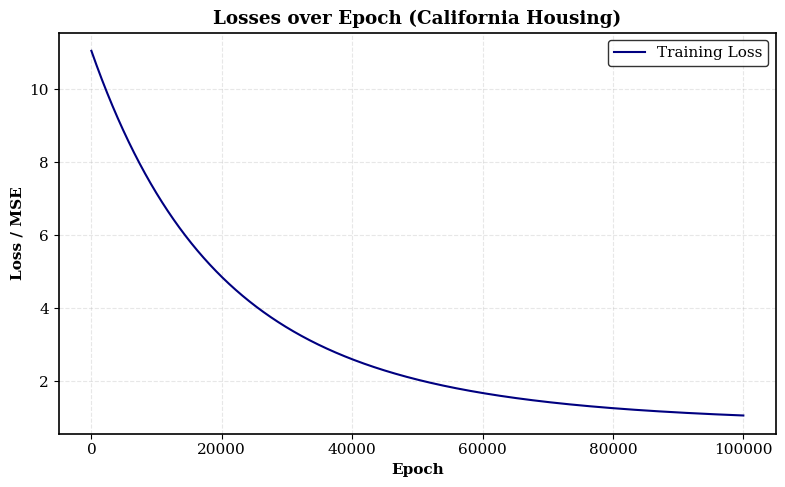

MSE on test set (California Housing): 1.2089561114344862


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["price"] = data.target

x = data.data
y = data.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

# Scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = GD(epoch=100000, lr=0.00001)
weights, bias, error, all_m, all_b =model.fit(x_train_scaled, y_train)
pred = model.predict(x_test_scaled, weights, bias)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "grid.alpha": 0.5
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(error, color='navy', linewidth=1.5, label="Training Loss")

ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Loss / MSE", fontweight="bold")
ax.set_title("Losses over Epoch (California Housing)", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()
test_mse = model.mse(x_test_scaled, y_test, weights, bias)
print(f"MSE on test set (California Housing): {test_mse}")